In [8]:
!pip install -q git+https://github.com/bowang-lab/MedSAM.git
!pip install -q albumentations

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.7/515.7 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.8/385.8 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 105.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 24.4 MB/s eta 0:00:00
   ━━━━

In [10]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
!nvidia-smi


Mon Apr 14 07:55:04 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             44W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [1]:
# %% Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install --force-reinstall numpy
import os
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 110.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
monai 1.4.0 requires numpy<2.0,>=1.24, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.


In [11]:
# download model
!wget -O medsam_vit_b.pth https://zenodo.org/records/10689643/files/medsam_vit_b.pth

--2025-04-22 18:55:02--  https://zenodo.org/records/10689643/files/medsam_vit_b.pth
Resolving zenodo.org (zenodo.org)... 188.185.45.92, 188.185.43.25, 188.185.48.194, ...
Connecting to zenodo.org (zenodo.org)|188.185.45.92|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375049145 (358M) [application/octet-stream]
Saving to: ‘medsam_vit_b.pth’

medsam_vit_b.pth    100%[===================>] 357.67M  21.9MB/s    in 17s     

2025-04-22 18:55:20 (21.2 MB/s) - ‘medsam_vit_b.pth’ saved [375049145/375049145]



In [14]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from skimage import transform
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:128"
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from segment_anything import sam_model_registry
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split


In [15]:
##############################
#      CONFIG & HYPERPARAMETERS
##############################

# # Training parameters
# NUM_EPOCHS = 10
# BATCH_SIZE = 4
# LEARNING_RATE = 1e-5
# ALPHA_DICE = 1.0   # Weight for Dice loss
# BETA_BCE = 1.0     # Weight for BCE loss

# Training parameters - TWO PHASES
PHASE1_EPOCHS = 4
PHASE2_EPOCHS = 4
PHASE1_LEARNING_RATE = 1e-5
PHASE2_LEARNING_RATE = 1e-5  # Lower learning rate for fine-tuning
BATCH_SIZE = 4
ALPHA_DICE = 1.0
BETA_BCE = 1.0

# Augmentation toggle and parameters
AUGMENTATION_ENABLED = True
augmentation_transform = A.Compose([
    A.ElasticTransform(alpha=1, sigma=50, p=0.5),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
    A.RandomBrightnessContrast(p=0.5)
], additional_targets={'mask': 'mask', 'bbox': 'bbox'})

# Bounding box expansion (e.g., 0.1 adds 10% of width/height margin on each side)
BOUNDING_BOX_EXPANSION = 0.05

# Paths to your dataset and MedSAM checkpoint
DATASET_DIR = "/content/drive/MyDrive/brain_tumor"  # Folder with .mat files
MedSAM_CKPT_PATH = "/content/medsam_vit_b.pth"       # Update path if needed

<ipython-input-15-a1d4d709385d>:25: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),


In [16]:
##############################
#         VISUALIZATION
##############################
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([251/255, 252/255, 30/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_box(box, ax):
    x0, y0, x1, y1 = box
    ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                 edgecolor='blue', facecolor=(0, 0, 0, 0), lw=2))

In [17]:
##############################
#     UTILITY FUNCTIONS
##############################
def expand_bbox(box_np, expansion, image_shape):
    """
    Expand the bounding box by a fraction of the image dimensions.
    box_np: array of shape (4,) in [x_min, y_min, x_max, y_max]
    expansion: fractional expansion (e.g., 0.1 adds 10% margin)
    image_shape: tuple (H, W)
    """
    H, W = image_shape
    x_min, y_min, x_max, y_max = box_np
    box_width = x_max - x_min
    box_height = y_max - y_min
    extra_w = box_width * expansion
    extra_h = box_height * expansion
    new_x_min = max(0, x_min - extra_w)
    new_y_min = max(0, y_min - extra_h)
    new_x_max = min(W, x_max + extra_w)
    new_y_max = min(H, y_max + extra_h)
    return np.array([new_x_min, new_y_min, new_x_max, new_y_max], dtype=np.float32)

def dice_loss(logits, target, smooth=1e-6):
    """
    Computes a differentiable Dice Loss.
    logits: raw network outputs, shape (B, 1, H, W)
    target: ground truth masks, shape (B, 1, H, W)
    """
    probs = torch.sigmoid(logits)
    intersection = (probs * target).sum(dim=(2,3))
    union = probs.sum(dim=(2,3)) + target.sum(dim=(2,3))
    dice = (2 * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()

def compound_loss(logits, target, alpha=ALPHA_DICE, beta=BETA_BCE):
    bce = torch.nn.functional.binary_cross_entropy_with_logits(logits, target)
    d_loss = dice_loss(logits, target)
    return alpha * d_loss + beta * bce

def medsam_forward(medsam_model, img_embed, box_1024, output_size=(1024, 1024)):
    """
    Forward pass through the prompt encoder and mask decoder.
    Returns raw logits (before sigmoid) upsampled to output_size.
    """
    if len(box_1024.shape) == 2:
        box_1024 = box_1024[:, None, :]  # shape (B, 1, 4)
    sparse_embeddings, dense_embeddings = medsam_model.prompt_encoder(
        points=None,
        boxes=box_1024,
        masks=None,
    )
    low_res_logits, _ = medsam_model.mask_decoder(
        image_embeddings=img_embed,
        image_pe=medsam_model.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse_embeddings,
        dense_prompt_embeddings=dense_embeddings,
        multimask_output=False,
    )
    logits_up = F.interpolate(
        low_res_logits,
        size=output_size,
        mode="bilinear",
        align_corners=False,
    )
    return logits_up

def dice_coefficient(pred, target):
    intersection = np.logical_and(pred, target).sum()
    return (2. * intersection) / (pred.sum() + target.sum() + 1e-8)
# Add a memory cleanup function
def cleanup_memory():
    """Force garbage collection and empty CUDA cache to free memory"""
    gc.collect()
    torch.cuda.empty_cache()

In [18]:
##############################
#   DATASET & PREPROCESSING
##############################
class BrainTumorDataset(Dataset):
    def __init__(self, mat_files, augmentation=None, bbox_expansion=0.0, target_size=1024):
        """
        mat_files: list of .mat file paths
        augmentation: Albumentations Compose (applied to image and mask)
        bbox_expansion: fractional expansion for bounding box
        target_size: final size for image and mask (assumes square images)
        """
        self.mat_files = mat_files
        self.augmentation = augmentation
        self.bbox_expansion = bbox_expansion
        self.target_size = target_size
        # Filter out files that don't contain 'cjdata'
        valid_files = []
        for file in mat_files:
            with h5py.File(file, 'r') as f:
                if 'cjdata' in f:
                    valid_files.append(file)
                else:
                    print(f"Skipping {file} (missing 'cjdata')")
        self.mat_files = valid_files  # Update file list to only include valid ones

    def __len__(self):
        return len(self.mat_files)

    def __getitem__(self, idx):
        mat_file_path = self.mat_files[idx]
        with h5py.File(mat_file_path, 'r') as f:
            img_mat = np.array(f['cjdata']['image'])
            tumor_mask = np.array(f['cjdata']['tumorMask'])
            tumor_border = np.array(f['cjdata']['tumorBorder'])[0]
            tumor_border = tumor_border.reshape(-1, 2)
            x_min, y_min = np.min(tumor_border, axis=0)
            x_max, y_max = np.max(tumor_border, axis=0)
            box_np = np.array([x_min, y_min, x_max, y_max], dtype=np.float32)

        original_shape = img_mat.shape[:2]  # (H, W)
        box_np = expand_bbox(box_np, self.bbox_expansion, original_shape)

        if img_mat.ndim == 2:
            img_3c = np.repeat(img_mat[:, :, None], 3, axis=-1)
        else:
            img_3c = img_mat.copy()

        img_resized = transform.resize(
            img_3c, (self.target_size, self.target_size),
            order=3, preserve_range=True, anti_aliasing=True
        ).astype(np.uint8)
        mask_resized = transform.resize(
            tumor_mask, (self.target_size, self.target_size),
            order=0, preserve_range=True, anti_aliasing=False
        ).astype(np.uint8)

        H_orig, W_orig = original_shape
        box_scaled = box_np / np.array([W_orig, H_orig, W_orig, H_orig]) * self.target_size

        data = {"image": img_resized, "mask": mask_resized, "bbox": box_scaled.tolist()}
        if self.augmentation is not None:
            augmented = self.augmentation(**data, )
            img_resized = augmented["image"]
            mask_resized = augmented["mask"]
            # If bbox is augmented, you can update it here.

        # Normalize image to [0,1]
        img_norm = (img_resized - img_resized.min()) / np.clip(img_resized.max() - img_resized.min(), a_min=1e-8, a_max=None)
        img_tensor = torch.tensor(img_norm).float().permute(2, 0, 1)
        mask_tensor = torch.tensor(mask_resized).float().unsqueeze(0)
        box_tensor = torch.tensor(box_scaled).float()

        return img_tensor, mask_tensor, box_tensor

In [19]:
import gc

# Clear memory before loading model
cleanup_memory()

device = "cuda:0" if torch.cuda.is_available() else "cpu"
medsam_model = sam_model_registry['vit_b'](checkpoint=MedSAM_CKPT_PATH)
medsam_model = medsam_model.to(device)

# Enable gradient checkpointing in the image encoder to save memory
medsam_model.image_encoder.use_gradient_checkpointing = True

# Freeze the entire image encoder to reduce memory requirements (optional)
# for param in medsam_model.image_encoder.parameters():
#    param.requires_grad = False

# Freeze the prompt encoder parameters (assumed domain-agnostic)
for param in medsam_model.prompt_encoder.parameters():
    param.requires_grad = False



In [6]:
import torch.cuda.amp as amp

mat_files = [os.path.join(DATASET_DIR, f) for f in os.listdir(DATASET_DIR) if f.endswith('.mat')]
mat_files.sort()
# Split dataset: 80% train, 20% validation
train_files, val_files = train_test_split(mat_files, test_size=0.2, random_state=42)

# Create smaller datasets if needed (for testing)
# train_files = train_files[:10]  # Uncommment to limit dataset size
# val_files = val_files[:5]      # Uncommment to limit dataset size

train_dataset = BrainTumorDataset(
    train_files,
    augmentation=augmentation_transform if AUGMENTATION_ENABLED else None,
    bbox_expansion=BOUNDING_BOX_EXPANSION,
    target_size=1024
)

# Reduce workers and pin_memory to save memory
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_dataset = BrainTumorDataset(
    val_files,
    augmentation=None,  # No augmentation for validation
    bbox_expansion=BOUNDING_BOX_EXPANSION,
    target_size=1024
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

# Set up mixed precision training
scaler = amp.GradScaler()

Skipping /content/drive/MyDrive/brain_tumor/cvind.mat (missing 'cjdata')


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
<ipython-input-6-f5eb0ae13f2d>:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/usr/local/lib/python3.11/dist-packages/torch/amp/grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


In [ ]:
    import torch.cuda.amp as amp

    scaler = amp.GradScaler()
    from torch.utils.checkpoint import checkpoint


<ipython-input-8-48e58cac530f>:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()


In [ ]:
##############################
#       TRAINING LOOP
##############################
# Phase 1: Initial training
print("Starting Phase 1 Training...")
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, medsam_model.parameters()),
    lr=PHASE1_LEARNING_RATE
)
scaler = amp.GradScaler()

for epoch in range(PHASE1_EPOCHS):
    medsam_model.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_dataloader):
        img_tensor, mask_tensor, box_tensor = batch
        img_tensor = img_tensor.to(device)
        # Don't retain computational graph between iterations
        img_tensor.requires_grad_(False)
        mask_tensor = mask_tensor.to(device)
        box_tensor = box_tensor.to(device).unsqueeze(1)  # (B, 1, 4)

        optimizer.zero_grad()

        # Mixed Precision: Use autocast
        with amp.autocast():
            # Use gradient checkpointing for the image encoder
            with torch.set_grad_enabled(True):
                img_tensor.requires_grad_(True)
                img_embed = checkpoint(medsam_model.image_encoder, img_tensor)

            # Process through the decoder
            logits = medsam_forward(
                medsam_model,
                img_embed,
                box_tensor,
                output_size=(1024, 1024)
            )

            loss = compound_loss(logits, mask_tensor, alpha=ALPHA_DICE, beta=BETA_BCE)

        # Scale the loss and backpropagate
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item() * img_tensor.size(0)

        # Free memory after each batch
        if batch_idx % 5 == 0:
            cleanup_memory()

        # Log progress
        if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1}, Batch {batch_idx}/{len(train_dataloader)}, Loss: {loss.item():.4f}")

    avg_train_loss = epoch_loss / len(train_dataset)

    # Validation phase
    medsam_model.eval()
    val_loss = 0.0
    val_dice = 0.0
    count = 0

    with torch.no_grad():
        for batch in val_dataloader:
            img_tensor, mask_tensor, box_tensor = batch
            img_tensor = img_tensor.to(device)
            mask_tensor = mask_tensor.to(device)
            box_tensor = box_tensor.to(device).unsqueeze(1)

            with amp.autocast():
                img_embed = medsam_model.image_encoder(img_tensor)
                logits = medsam_forward(
                    medsam_model,
                    img_embed,
                    box_tensor,
                    output_size=(1024, 1024)
                )
                loss_val = compound_loss(logits, mask_tensor, alpha=ALPHA_DICE, beta=BETA_BCE)

            val_loss += loss_val.item() * img_tensor.size(0)

            probs = torch.sigmoid(logits)
            pred_mask = (probs > 0.5).float()
            # Compute dice for each sample in the batch
            for i in range(img_tensor.size(0)):
                dice = dice_coefficient(
                    pred_mask[i].cpu().numpy().squeeze(),
                    mask_tensor[i].cpu().numpy().squeeze()
                )
                val_dice += dice
            count += img_tensor.size(0)

    avg_val_loss = val_loss / len(val_dataset)
    avg_val_dice = val_dice / count

    # print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Train Loss: {avg_train_loss:.4f}, "
    #       f"Val Loss: {avg_val_loss:.4f}, Val Dice: {avg_val_dice:.3f}")
    print(f"Phase 1 - Epoch [{epoch+1}/{PHASE1_EPOCHS}], Train Loss: {avg_train_loss:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, Val Dice: {avg_val_dice:.3f}")


    # Save checkpoint at end of each epoch to prevent data loss
    # Save checkpoint after each epoch
    torch.save({
        'phase': 1,
        'epoch': epoch,
        'model_state_dict': medsam_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'val_dice': avg_val_dice
    }, f"medsam_phase1_epoch_{epoch+1}.pt")

    # Clean up after each epoch
    cleanup_memory()
# Save final Phase 1 model
torch.save(medsam_model.state_dict(), "medsam_phase1_final.pt")




Starting Phase 1 Training...


<ipython-input-9-b2fba8333fbb>:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
<ipython-input-9-b2fba8333fbb>:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 1, Batch 0/613, Loss: 0.8920
Epoch 1, Batch 10/613, Loss: 0.8053
Epoch 1, Batch 20/613, Loss: 0.7899
Epoch 1, Batch 30/613, Loss: 1.1967
Epoch 1, Batch 40/613, Loss: 1.0869
Epoch 1, Batch 50/613, Loss: 0.9943
Epoch 1, Batch 60/613, Loss: 1.0617
Epoch 1, Batch 70/613, Loss: 0.8900
Epoch 1, Batch 80/613, Loss: 1.1393
Epoch 1, Batch 90/613, Loss: 1.0808
Epoch 1, Batch 100/613, Loss: 0.8990
Epoch 1, Batch 110/613, Loss: 0.6349
Epoch 1, Batch 120/613, Loss: 0.9094
Epoch 1, Batch 130/613, Loss: 1.0588
Epoch 1, Batch 140/613, Loss: 0.9682
Epoch 1, Batch 150/613, Loss: 1.1490
Epoch 1, Batch 160/613, Loss: 0.9610
Epoch 1, Batch 170/613, Loss: 1.1388
Epoch 1, Batch 180/613, Loss: 0.7190
Epoch 1, Batch 190/613, Loss: 0.9414
Epoch 1, Batch 200/613, Loss: 0.9588
Epoch 1, Batch 210/613, Loss: 0.6509
Epoch 1, Batch 220/613, Loss: 0.7939
Epoch 1, Batch 230/613, Loss: 1.0452
Epoch 1, Batch 240/613, Loss: 0.9097
Epoch 1, Batch 250/613, Loss: 0.9218
Epoch 1, Batch 260/613, Loss: 0.9170
Epoch 1, Bat

<ipython-input-9-b2fba8333fbb>:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Phase 1 - Epoch [1/4], Train Loss: 0.8175, Val Loss: 0.5035, Val Dice: 0.561


<ipython-input-9-b2fba8333fbb>:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 2, Batch 0/613, Loss: 0.6365
Epoch 2, Batch 10/613, Loss: 0.4070
Epoch 2, Batch 20/613, Loss: 0.4127
Epoch 2, Batch 30/613, Loss: 0.6632
Epoch 2, Batch 40/613, Loss: 0.5552
Epoch 2, Batch 50/613, Loss: 0.5770
Epoch 2, Batch 60/613, Loss: 0.3596
Epoch 2, Batch 70/613, Loss: 0.2366
Epoch 2, Batch 80/613, Loss: 0.4487
Epoch 2, Batch 90/613, Loss: 0.2162
Epoch 2, Batch 100/613, Loss: 0.3636
Epoch 2, Batch 110/613, Loss: 0.3742
Epoch 2, Batch 120/613, Loss: 0.2660
Epoch 2, Batch 130/613, Loss: 0.4992
Epoch 2, Batch 140/613, Loss: 0.4670
Epoch 2, Batch 150/613, Loss: 0.4565
Epoch 2, Batch 160/613, Loss: 0.4358
Epoch 2, Batch 170/613, Loss: 0.5377
Epoch 2, Batch 180/613, Loss: 0.3131
Epoch 2, Batch 190/613, Loss: 0.6559
Epoch 2, Batch 200/613, Loss: 0.2938
Epoch 2, Batch 210/613, Loss: 0.3261
Epoch 2, Batch 220/613, Loss: 0.6174
Epoch 2, Batch 230/613, Loss: 0.2385
Epoch 2, Batch 240/613, Loss: 0.6704
Epoch 2, Batch 250/613, Loss: 0.4620
Epoch 2, Batch 260/613, Loss: 0.2142
Epoch 2, Bat

In [ ]:
print("Starting Phase 2 Training...")

# Load Phase 1 checkpoint
medsam_model.load_state_dict(torch.load("/content/medsam_phase1_final.pt", map_location=device))

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, medsam_model.parameters()),
    lr=PHASE2_LEARNING_RATE
)
scaler = amp.GradScaler()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

for epoch in range(PHASE2_EPOCHS):
    medsam_model.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_dataloader):
        img_tensor, mask_tensor, box_tensor = batch
        img_tensor = img_tensor.to(device)
        img_tensor.requires_grad_(False)
        mask_tensor = mask_tensor.to(device)
        box_tensor = box_tensor.to(device).unsqueeze(1)

        optimizer.zero_grad()

        with amp.autocast():
            with torch.set_grad_enabled(True):
                img_tensor.requires_grad_(True)
                img_embed = medsam_model.image_encoder(img_tensor)

            logits = medsam_forward(
                medsam_model,
                img_embed,
                box_tensor,
                output_size=(1024, 1024)
            )

            loss = compound_loss(logits, mask_tensor, alpha=ALPHA_DICE, beta=BETA_BCE)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item() * img_tensor.size(0)

        if batch_idx % 5 == 0:
            cleanup_memory()

        if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1}, Batch {batch_idx}/{len(train_dataloader)}, Loss: {loss.item():.4f}")

    avg_train_loss = epoch_loss / len(train_dataset)

    medsam_model.eval()
    val_loss = 0.0
    val_dice = 0.0
    count = 0

    with torch.no_grad():
        for batch in val_dataloader:
            img_tensor, mask_tensor, box_tensor = batch
            img_tensor = img_tensor.to(device)
            mask_tensor = mask_tensor.to(device)
            box_tensor = box_tensor.to(device).unsqueeze(1)

            with amp.autocast():
                img_embed = medsam_model.image_encoder(img_tensor)
                logits = medsam_forward(
                    medsam_model,
                    img_embed,
                    box_tensor,
                    output_size=(1024, 1024)
                )
                loss_val = compound_loss(logits, mask_tensor, alpha=ALPHA_DICE, beta=BETA_BCE)

            val_loss += loss_val.item() * img_tensor.size(0)

            probs = torch.sigmoid(logits)
            pred_mask = (probs > 0.5).float()
            for i in range(img_tensor.size(0)):
                dice = dice_coefficient(
                    pred_mask[i].cpu().numpy().squeeze(),
                    mask_tensor[i].cpu().numpy().squeeze()
                )
                val_dice += dice
            count += img_tensor.size(0)

    avg_val_loss = val_loss / len(val_dataset)
    avg_val_dice = val_dice / count

    print(f"Phase 2 - Epoch [{epoch+1}/{PHASE2_EPOCHS}], Train Loss: {avg_train_loss:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, Val Dice: {avg_val_dice:.3f}")

    torch.save({
        'phase': 2,
        'epoch': epoch,
        'model_state_dict': medsam_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'val_dice': avg_val_dice
    }, f"medsam_phase2_epoch_{epoch+1}.pt")

    cleanup_memory()
    scheduler.step()

# Save final Phase 2 model

Starting Phase 2 Training...


<ipython-input-10-d63b22eed389>:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
<ipython-input-10-d63b22eed389>:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Epoch 1, Batch 0/613, Loss: 0.2309
Epoch 1, Batch 10/613, Loss: 0.1420
Epoch 1, Batch 20/613, Loss: 0.1510
Epoch 1, Batch 30/613, Loss: 0.3374
Epoch 1, Batch 40/613, Loss: 0.1334
Epoch 1, Batch 50/613, Loss: 0.1816
Epoch 1, Batch 60/613, Loss: 0.1151
Epoch 1, Batch 70/613, Loss: 0.1574
Epoch 1, Batch 80/613, Loss: 0.1353
Epoch 1, Batch 90/613, Loss: 0.1257
Epoch 1, Batch 100/613, Loss: 0.3437
Epoch 1, Batch 110/613, Loss: 0.0905
Epoch 1, Batch 120/613, Loss: 0.2445
Epoch 1, Batch 130/613, Loss: 0.1286
Epoch 1, Batch 140/613, Loss: 0.1901
Epoch 1, Batch 150/613, Loss: 0.2259
Epoch 1, Batch 160/613, Loss: 0.0740
Epoch 1, Batch 170/613, Loss: 0.2977
Epoch 1, Batch 180/613, Loss: 0.1938
Epoch 1, Batch 190/613, Loss: 0.0939
Epoch 1, Batch 200/613, Loss: 0.1050
Epoch 1, Batch 210/613, Loss: 0.3973
Epoch 1, Batch 220/613, Loss: 0.1763
Epoch 1, Batch 230/613, Loss: 0.2251
Epoch 1, Batch 240/613, Loss: 0.2378
Epoch 1, Batch 250/613, Loss: 0.1409
Epoch 1, Batch 260/613, Loss: 0.2708
Epoch 1, Bat

<ipython-input-10-d63b22eed389>:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Phase 2 - Epoch [1/4], Train Loss: 0.2003, Val Loss: 0.2302, Val Dice: 0.801
Epoch 2, Batch 0/613, Loss: 0.1176
Epoch 2, Batch 10/613, Loss: 0.1619
Epoch 2, Batch 20/613, Loss: 0.1775
Epoch 2, Batch 30/613, Loss: 0.2695
Epoch 2, Batch 40/613, Loss: 0.1478
Epoch 2, Batch 50/613, Loss: 0.1220
Epoch 2, Batch 60/613, Loss: 0.1996
Epoch 2, Batch 70/613, Loss: 0.2382
Epoch 2, Batch 80/613, Loss: 0.4009
Epoch 2, Batch 90/613, Loss: 0.0828
Epoch 2, Batch 100/613, Loss: 0.1089
Epoch 2, Batch 110/613, Loss: 0.3740
Epoch 2, Batch 120/613, Loss: 0.1795
Epoch 2, Batch 130/613, Loss: 0.1356
Epoch 2, Batch 140/613, Loss: 0.1533
Epoch 2, Batch 150/613, Loss: 0.2087
Epoch 2, Batch 160/613, Loss: 0.1394
Epoch 2, Batch 170/613, Loss: 0.3177
Epoch 2, Batch 180/613, Loss: 0.0989
Epoch 2, Batch 190/613, Loss: 0.1490
Epoch 2, Batch 200/613, Loss: 0.1878
Epoch 2, Batch 210/613, Loss: 0.1513
Epoch 2, Batch 220/613, Loss: 0.2190
Epoch 2, Batch 230/613, Loss: 0.0908
Epoch 2, Batch 240/613, Loss: 0.1803
Epoch 2, 

Inference Dice Score on sample: 0.932


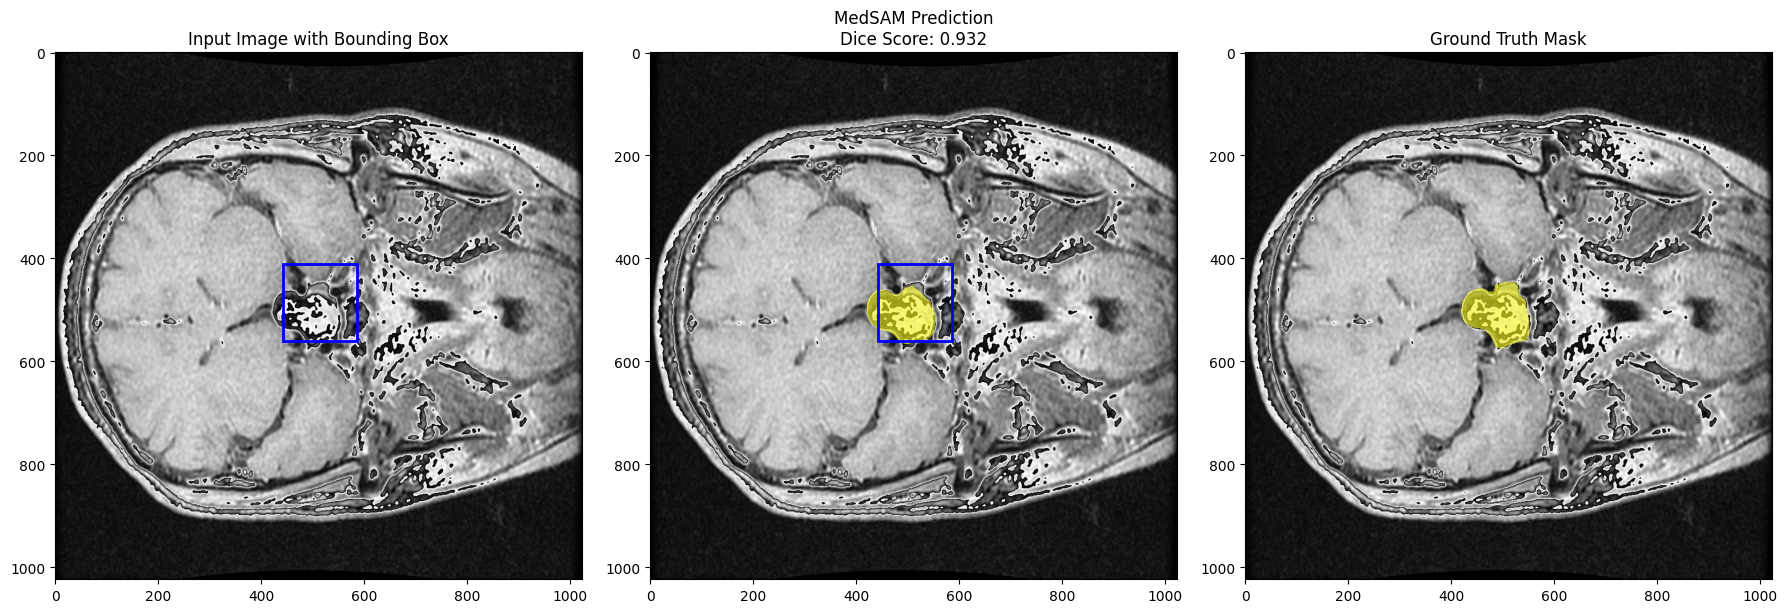

In [29]:
# Load your trained Phase 2 model.
medsam_model.load_state_dict(torch.load("medsam_phase2_best (1).pt", map_location=device))
medsam_model.eval()

# ----------------------------
#  INFERENCE & VISUALIZATION
# ----------------------------
@torch.no_grad()
def medsam_inference(medsam_model, img_embed, box_1024, H, W):
    logits = medsam_forward(medsam_model, img_embed, box_1024, output_size=(H, W))
    probs = torch.sigmoid(logits)
    seg_mask = (probs > 0.5).float().squeeze().cpu().numpy()
    return seg_mask

# Choose one validation sample.
sample_file = val_files[56]  # Change the index if needed.
sample_dataset = BrainTumorDataset([sample_file],
                                   augmentation=None,
                                   bbox_expansion=BOUNDING_BOX_EXPANSION,
                                   target_size=1024)
img_tensor, mask_tensor, box_tensor = sample_dataset[0]

# Define image dimensions.
H, W = 1024, 1024

# Prepare input tensors: add batch dimensions and move to device.
img_tensor = img_tensor.unsqueeze(0).to(device)
box_tensor = box_tensor.unsqueeze(0).unsqueeze(1).to(device)

# Run inference.
with torch.no_grad():
    image_embedding = medsam_model.image_encoder(img_tensor)
    pred_mask = medsam_inference(medsam_model, image_embedding, box_tensor, H, W)

# Compute the Dice coefficient.
dice_score = dice_coefficient(pred_mask, mask_tensor.squeeze().numpy())
print(f"Inference Dice Score on sample: {dice_score:.3f}")

# Prepare image and mask for visualization.
img_np = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
mask_np = mask_tensor.squeeze().cpu().numpy()
box_np = box_tensor.squeeze().cpu().numpy()

# Create subplots for input image, prediction, and ground truth.
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Input image with bounding box.
ax[0].imshow(img_np, cmap='gray')
show_box(box_np, ax[0])
ax[0].set_title("Input Image with Bounding Box")

# Prediction overlay.
ax[1].imshow(img_np, cmap='gray')
show_mask(pred_mask, ax[1])
show_box(box_np, ax[1])
ax[1].set_title(f"MedSAM Prediction\nDice Score: {dice_score:.3f}")

# Ground truth mask.
ax[2].imshow(img_np, cmap='gray')
show_mask(mask_np, ax[2])
ax[2].set_title("Ground Truth Mask")

plt.tight_layout()
plt.show()

In [ ]:
import torch

# Load the checkpoint from epoch 3
checkpoint = torch.load("/content/medsam_phase2_epoch_4.pt", map_location=device, weights_only=False)

# Load the model's state dictionary
medsam_model.load_state_dict(checkpoint["model_state_dict"])

# Save the best model as the final one
torch.save(medsam_model.state_dict(), "/content/medsam_phase2_best.pt")

print("Final model saved from Epoch 8 as 'medsam_phase2_best.pt'!")

Final model saved from Epoch 8 as 'medsam_phase2_best.pt'!
